In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

%matplotlib inline
sns.set(style="whitegrid", context="notebook")

In [2]:
# Load the heart disease dataset from a public URL
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

In [3]:
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [5]:
print(df.shape)

(303, 14)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [10]:
# Let's define a cleaned version for sampling
df_clean = df.copy()

# Treat some integer-coded columns as categorical
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("category")

df_clean.dtypes

,0
age,int64
sex,category
cp,category
trestbps,int64
chol,int64
fbs,category
restecg,category
thalach,int64
exang,category
oldpeak,float64


In [11]:
target_numeric = "chol"  # serum cholesterol
df_clean[target_numeric].describe()

,chol
count,303.000000
mean,246.264026
std,51.830751
min,126.000000
25%,211.000000
50%,240.000000
75%,274.500000
max,564.000000


Simple Random Sampling

Questions:
- What happens to the mean and standard deviation when we:
  - Take a small sample?
  - Take a larger sample?
- Do larger samples give more stable estimates?

In [12]:

np.random.seed(42)  # for reproducibility

sample_50  = df_clean.sample(50, random_state=1)
sample_100 = df_clean.sample(100, random_state=2)
sample_200 = df_clean.sample(200, random_state=3)

In [13]:

rows = []

for label, subset in [
    ("Full data", df_clean),
    ("Sample 50", sample_50),
    ("Sample 100", sample_100),
    ("Sample 200", sample_200),
]:
    mean_val = subset[target_numeric].mean()
    std_val  = subset[target_numeric].std()
    rows.append({
        "Dataset": label,
        "Mean_cholesterol": mean_val,
        "Std_cholesterol": std_val
    })

sampling_summary = pd.DataFrame(rows)
sampling_summary

,Dataset,Mean_cholesterol,Std_cholesterol
0,Full data,246.264026,51.830751
1,Sample 50,241.840000,54.117544
2,Sample 100,245.890000,59.084240
3,Sample 200,245.890000,53.630767


In [14]:

sampling_summary.style.format({"Mean_cholesterol": "{:.2f}", "Std_cholesterol": "{:.2f}"})

,Dataset,Mean_cholesterol,Std_cholesterol
0,Full data,246.26,51.83
1,Sample 50,241.84,54.12
2,Sample 100,245.89,59.08
3,Sample 200,245.89,53.63



Stratified Sampling

Goal:
- Preserve the proportion of key groups (e.g., sex)
- Reduce the risk of under-representing one group
- Often more fair and stable, especially in healthcare

In [15]:


df_clean["sex"].value_counts(normalize=True)

,proportion
sex,
1,0.683168
0,0.316832


In [16]:
def stratified_sample(df, group_col, n, random_state=None):
    np.random.seed(random_state)
    proportions = df[group_col].value_counts(normalize=True)
    # Determine how many from each group
    group_sizes = (proportions * n).round().astype(int)

    samples = []
    for group_value, group_n in group_sizes.items():
        group_df = df[df[group_col] == group_value]
        # Guard in case rounding overshoots
        group_n = min(group_n, len(group_df))
        samples.append(group_df.sample(group_n, random_state=random_state))

    result = pd.concat(samples).sample(frac=1, random_state=random_state)  # shuffle
    return result

strat_200 = stratified_sample(df_clean, group_col="sex", n=200, random_state=42)

strat_200["sex"].value_counts(normalize=True)

,proportion
sex,
1,0.685
0,0.315


In [17]:
# Compare cholesterol statistics: full vs simple random vs stratified
rows = []

for label, subset in [
    ("Full data", df_clean),
    ("Simple Random 200", sample_200),
    ("Stratified by sex 200", strat_200),
]:
    rows.append({
        "Dataset": label,
        "Mean_cholesterol": subset[target_numeric].mean(),
        "Std_cholesterol": subset[target_numeric].std(),
        "N": len(subset)
    })

comparison = pd.DataFrame(rows)
comparison

,Dataset,Mean_cholesterol,Std_cholesterol,N
0,Full data,246.264026,51.830751,303
1,Simple Random 200,245.890000,53.630767,200
2,Stratified by sex 200,245.865000,46.969752,200



Comparing Two Groups

Example question:
- "Is average cholesterol different between sex = 0 and sex = 1?"

We will:
- Compute group means
- Compute a confidence interval for the difference
- Run a basic t-test
- Explain the result in simple language

In [18]:

group0 = df_clean[df_clean["sex"] == 0][target_numeric]
group1 = df_clean[df_clean["sex"] == 1][target_numeric]

group0.describe(), group1.describe()

(count     96.000000
 mean     261.302083
 std       65.088946
 min      141.000000
 25%      214.750000
 50%      253.000000
 75%      296.750000
 max      564.000000
 Name: chol, dtype: float64,
 count    207.000000
 mean     239.289855
 std       42.782392
 min      126.000000
 25%      208.000000
 50%      235.000000
 75%      268.000000
 max      353.000000
 Name: chol, dtype: float64)

In [19]:

mean_diff = group1.mean() - group0.mean()
mean_diff

np.float64(-22.012228260869534)

In [20]:
# Standard error of the difference in means
n0 = group0.shape[0]
n1 = group1.shape[0]

s0_sq = group0.var(ddof=1)
s1_sq = group1.var(ddof=1)

se_diff = np.sqrt(s0_sq / n0 + s1_sq / n1)
se_diff

np.float64(7.2782646269117866)

In [21]:
z = 1.96  # approximate z-value for 95% confidence
ci_lower = mean_diff - z * se_diff
ci_upper = mean_diff + z * se_diff

(ci_lower, ci_upper)

(np.float64(-36.27762692961664), np.float64(-7.746829592122433))

In [22]:


t_stat, p_value = stats.ttest_ind(group1, group0, equal_var=False)
t_stat, p_value

(np.float64(-3.02437866568881), np.float64(0.00298541775416255))

Simulation: Sampling Variability

Question:
- If we repeatedly take random samples and compute the mean cholesterol each time,
  what does the distribution of those sample means look like?

In [23]:
np.random.seed(123)

sample_size = 100
num_iterations = 200

mean_list = []

for i in range(num_iterations):
    sample = df_clean.sample(sample_size, replace=True)  # bootstrap-style sampling
    mean_list.append(sample[target_numeric].mean())

len(mean_list), mean_list[:5]

(200,
 [np.float64(249.41),
  np.float64(249.79),
  np.float64(245.02),
  np.float64(240.22),
  np.float64(247.22)])

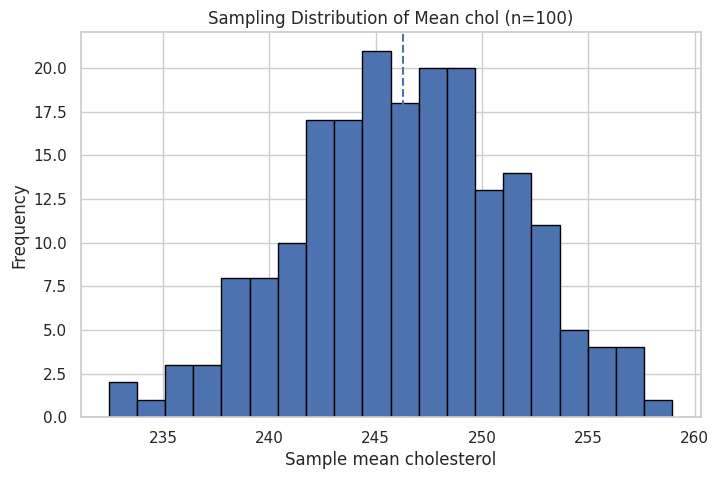

In [24]:

plt.figure(figsize=(8, 5))
plt.hist(mean_list, bins=20, edgecolor="black")
plt.axvline(df_clean[target_numeric].mean(), linestyle="--")
plt.title(f"Sampling Distribution of Mean {target_numeric} (n={sample_size})")
plt.xlabel("Sample mean cholesterol")
plt.ylabel("Frequency")
plt.show()

Ethical Reflection on Sampling

Discussion questions:
- What happens if our sample under-represents certain groups?
- Could decisions based on biased samples harm real patients?
- How can random and stratified sampling help reduce unfairness?


Wrap-Up: Sampling & Statistics in Practice

Today we:
- Loaded a real clinical dataset into Pandas
- Performed simple random sampling at different sizes
- Performed stratified sampling by sex
- Computed and compared means and standard deviations
- Ran a basic t-test to compare groups
- Simulated sampling variability and visualized the distribution of sample means
- Reflected on fairness and ethics in sampling

Key ideas:
- Larger samples → more stable estimates (on average)
- Stratified sampling → better representation of key groups
- Sampling variability → estimates always move, never fixed
- Ethical sampling → essential for fair decisions in healthcare